In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/kanchana1990/biomedical-research-abstracts-20242026/biomedical_research_abstracts_2024_2026.csv


# Basic setup

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from wordcloud import WordCloud
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import warnings

from plotly.subplots import make_subplots

warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
# Set style for better visualizations
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 12



# Load the dataset

In [3]:

df = pd.read_csv('/kaggle/input/datasets/kanchana1990/biomedical-research-abstracts-20242026/biomedical_research_abstracts_2024_2026.csv')


In [4]:
df.head()

,pmid,title,abstract,abstract_words,journal,pub_year,pub_month,pub_month_num,month_year,doi,authors_count,country,research_type,keywords,major_topic,language,open_access
0,41869676,"The genome sequence of the bloodfluke planorb,...",We present a genome assembly from an individua...,57,Wellcome open research,2024,Unknown,0,Unknown-2024,10.12688/wellcomeopenres.22819.2,7,UK,Journal Article,NaN,NaN,eng,True
1,41841041,An exploratory study of critical incidents wit...,Leadership changes within public organizations...,250,F1000Research,2024,Unknown,0,Unknown-2024,10.12688/f1000research.142942.2,4,Indonesia,Journal Article,Leadership; Humans; Anxiety; Organizational In...,Leadership,eng,True
2,41797731,From Mary Shelley to Netflix: a Pan-European p...,Scientific knowledge of the human brain has ca...,244,Frontiers in neuroscience,2024,Unknown,0,Unknown-2024,10.3389/fnins.2024.1278640,2,Spain,Journal Article,NaN,NaN,eng,True
3,41726542,Improving electronic health record processing ...,Large language models (LLMs) excel in natural ...,134,AMIA ... Annual Symposium proceedings. AMIA Sy...,2024,Unknown,0,Unknown-2024,NaN,4,USA,Journal Article,Natural Language Processing; Electronic Health...,Natural Language Processing,eng,True
4,41726541,Developing a User-Centered Mobile Application ...,This study is part of the OsteoPorotic fracTur...,136,AMIA ... Annual Symposium proceedings. AMIA Sy...,2024,Unknown,0,Unknown-2024,NaN,13,USA,Journal Article,Mobile Applications; Humans; Skilled Nursing F...,Mobile Applications,eng,True


In [5]:
df.describe()

,pmid,abstract_words,pub_year,pub_month_num,authors_count
count,1.268320e+05,126832.000000,126832.000000,126832.000000,126832.000000
mean,3.904828e+07,224.375063,2024.244410,2.816758,7.158028
std,1.285640e+06,70.734550,0.524044,3.123171,12.246380
min,3.343327e+07,50.000000,2024.000000,0.000000,0.000000
25%,3.821511e+07,179.000000,2024.000000,1.000000,4.000000
50%,3.828134e+07,224.000000,2024.000000,1.000000,6.000000
75%,3.989876e+07,261.000000,2024.000000,4.000000,9.000000
max,4.188182e+07,998.000000,2026.000000,12.000000,2932.000000


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 126832 entries, 0 to 126831
Data columns (total 17 columns):
 #   Column          Non-Null Count   Dtype 
---  ------          --------------   ----- 
 0   pmid            126832 non-null  int64 
 1   title           126832 non-null  object
 2   abstract        126832 non-null  object
 3   abstract_words  126832 non-null  int64 
 4   journal         126832 non-null  object
 5   pub_year        126832 non-null  int64 
 6   pub_month       126832 non-null  object
 7   pub_month_num   126832 non-null  int64 
 8   month_year      126832 non-null  object
 9   doi             125898 non-null  object
 10  authors_count   126832 non-null  int64 
 11  country         126832 non-null  object
 12  research_type   126832 non-null  object
 13  keywords        66759 non-null   object
 14  major_topic     66755 non-null   object
 15  language        126832 non-null  object
 16  open_access     126832 non-null  bool  
dtypes: bool(1), int64(5), object(

# Data preprocessing

In [7]:


df['pub_year'] = df['pub_year'].astype(int)
df['open_access'] = df['open_access'].astype(bool)
df['pub_month_num'] = pd.to_numeric(df['pub_month_num'], errors='coerce')
df['date_for_analysis'] = pd.to_datetime(df['month_year'], errors='coerce')

# Create derived features
df['keyword_count'] = df['keywords'].fillna('').apply(lambda x: len(x.split(';')) if x else 0)
df['has_doi'] = df['doi'].notna()
df['author_category'] = pd.cut(df['authors_count'], 
                                bins=[0, 1, 5, 10, 50, float('inf')],
                                labels=['Single', '2-5', '6-10', '11-50', '50+'])

# Dataset Overview & Quality Metrics

In [8]:



# Year distribution (sorted)
year_counts = df['pub_year'].value_counts().sort_index()

# Open access
oa_counts = df['open_access'].value_counts()

# Abstract length
abstract_words = df['abstract_words'].dropna()

# Top journals (clean + truncate long names)
top_journals = df['journal'].value_counts().head(10).sort_values()
top_journals.index = [
    j[:40] + "..." if len(j) > 40 else j
    for j in top_journals.index
]


# Create Subplots


fig = make_subplots(
    rows=2, cols=2,
    subplot_titles=(
        'Publications by Year',
        'Open Access Distribution',
        'Abstract Length Distribution',
        'Top Journals'
    ),
    horizontal_spacing=0.12, 
    vertical_spacing=0.15
)


# 1. Publications by Year


fig.add_trace(
    go.Bar(
        x=year_counts.index,
        y=year_counts.values,
        name='Publications'
    ),
    row=1, col=1
)


# 2. Open Access (BAR > PIE)


fig.add_trace(
    go.Bar(
        x=['Open Access', 'Closed Access'],
        y=oa_counts.values,
        name='Access'
    ),
    row=1, col=2
)


# 3. Abstract Length Histogram


fig.add_trace(
    go.Histogram(
        x=abstract_words,
        nbinsx=40,
        name='Abstract Length'
    ),
    row=2, col=1
)


# 4. Top Journals (Horizontal Bar)


fig.add_trace(
    go.Bar(
        x=top_journals.values,
        y=top_journals.index,
        orientation='h',
        name='Journals'
    ),
    row=2, col=2
)



fig.update_layout(
    title=" Clean Dataset Overview Dashboard",
    height=850,
    width=1300,  
    showlegend=False,
    template="plotly_white",
    margin=dict(l=100, r=80, t=80, b=80)
)

# Axis Fixes


fig.update_yaxes(automargin=True)  
fig.update_xaxes(tickangle=0)

# Optional: smaller font for long labels
fig.update_yaxes(tickfont=dict(size=10), row=2, col=2)



fig.show()

# Temporal Analysis with Cumulative Trends

Records with valid dates: 106,166 / 126,832
Records with unknown months: 20,666


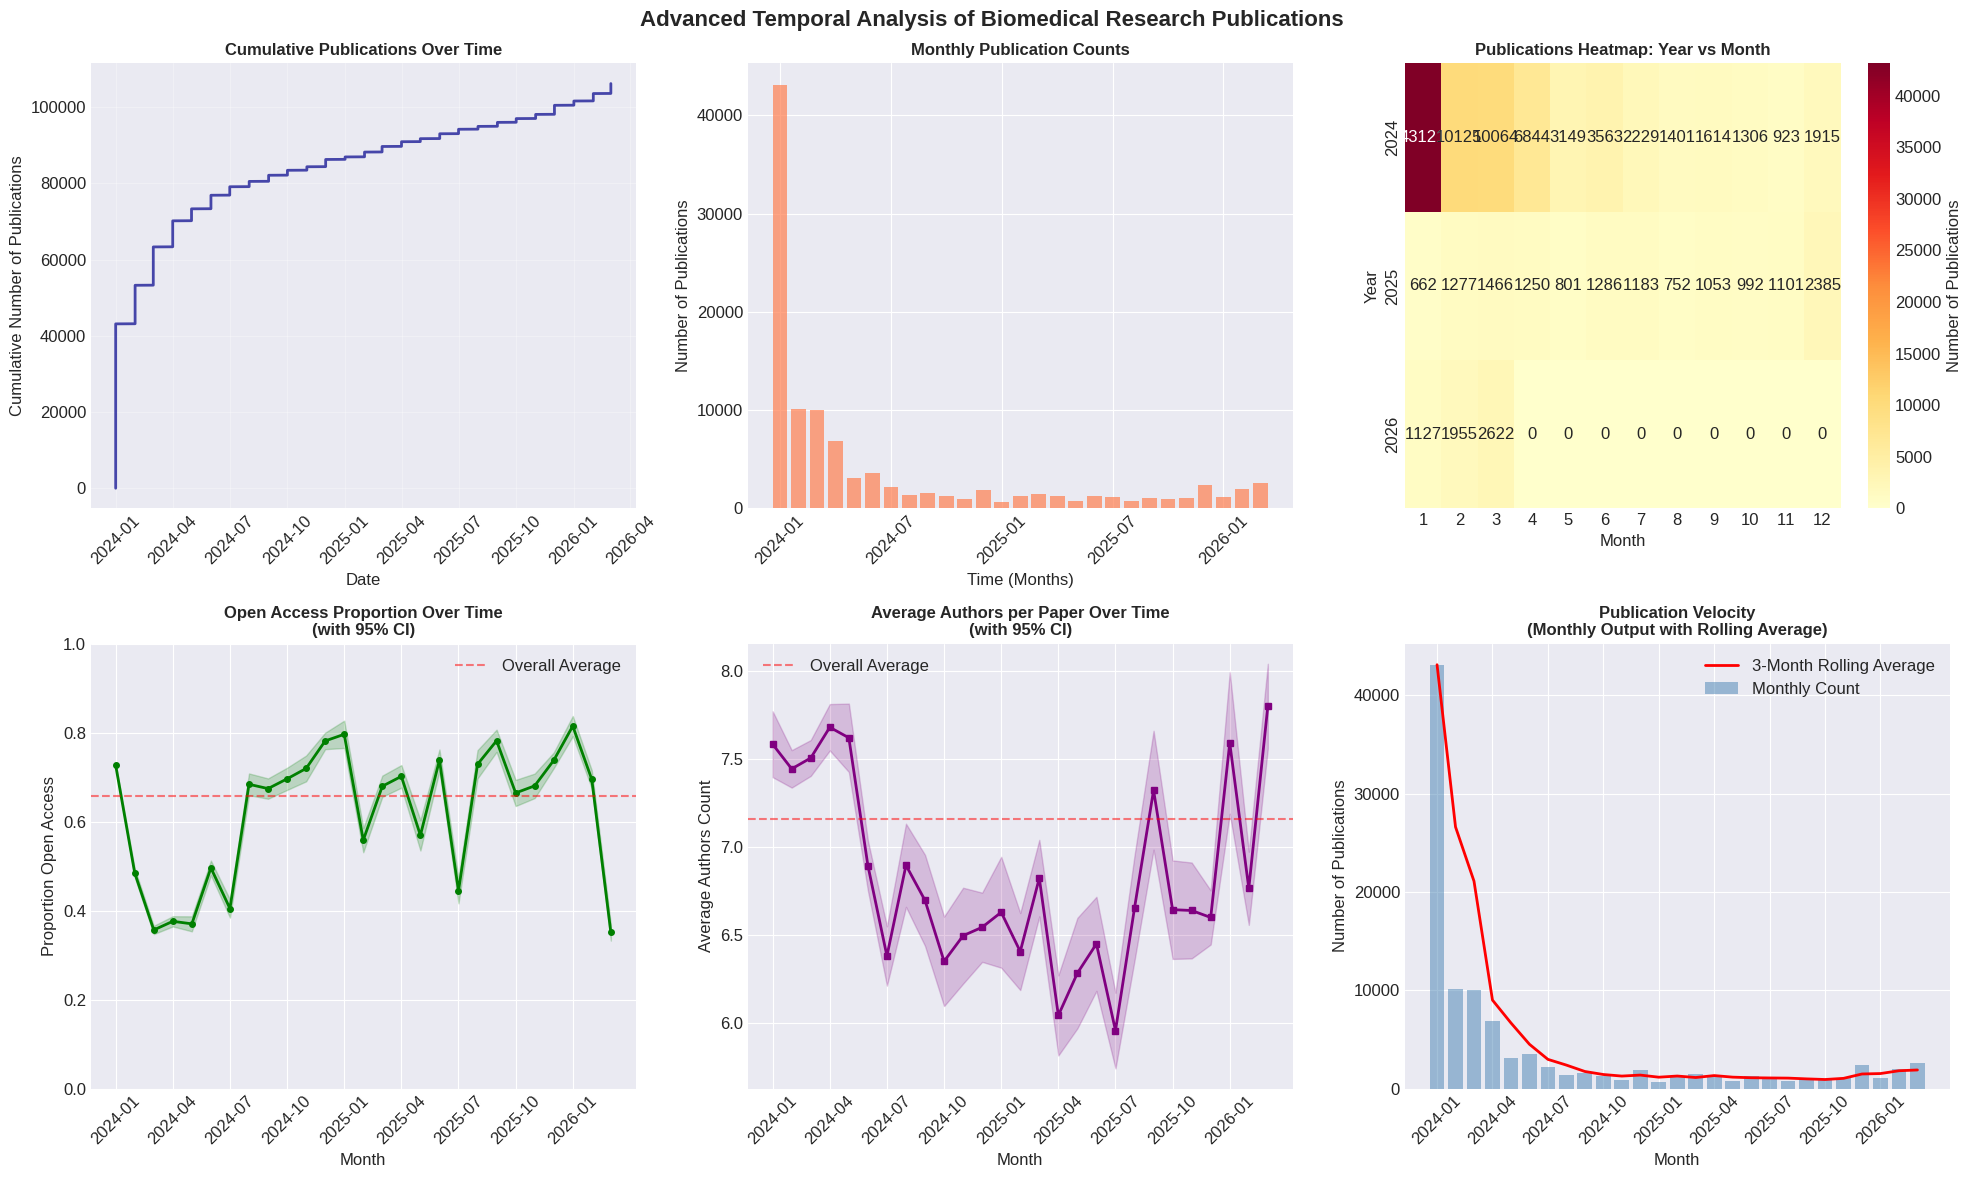

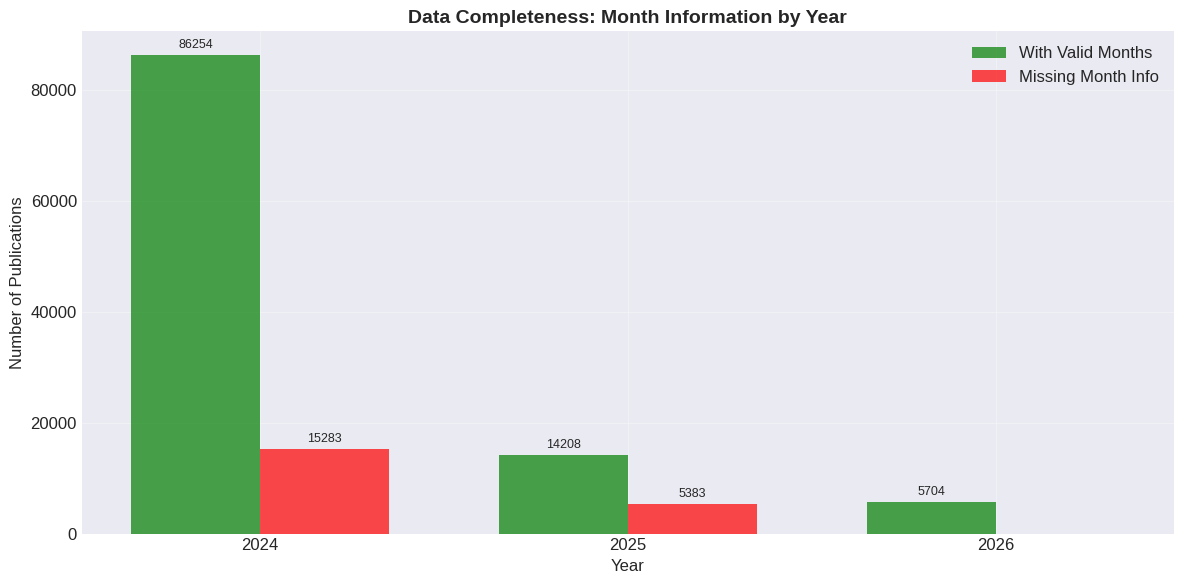

TEMPORAL PATTERN ANALYSIS SUMMARY

 Publication Trends by Year:
          Publications  Open Access Rate  Avg Authors  Avg Abstract Length
pub_year                                                                  
2024            101537              0.65         7.29               226.17
2025             19591              0.75         6.40               215.26
2026              5704              0.56         7.40               223.69

 Growth Rates:
  2024 → 2025: -80.7% growth in publications
  2025 → 2026: -70.9% growth in publications

 Missing Data Impact:
  Total records with missing month: 20,666 (16.3%)
  These records are excluded from time-series analysis
  Recommendation: Use year-level analysis for these records

 Temporal Distribution Insights:
  Months with most publications:       date  count
2024-01-01  43121
2024-02-01  10125
2024-03-01  10064
2024-04-01   6844
2024-06-01   3563
  Months with fewest publications:       date  count
2025-01-01    662
2025-08-01    752
20

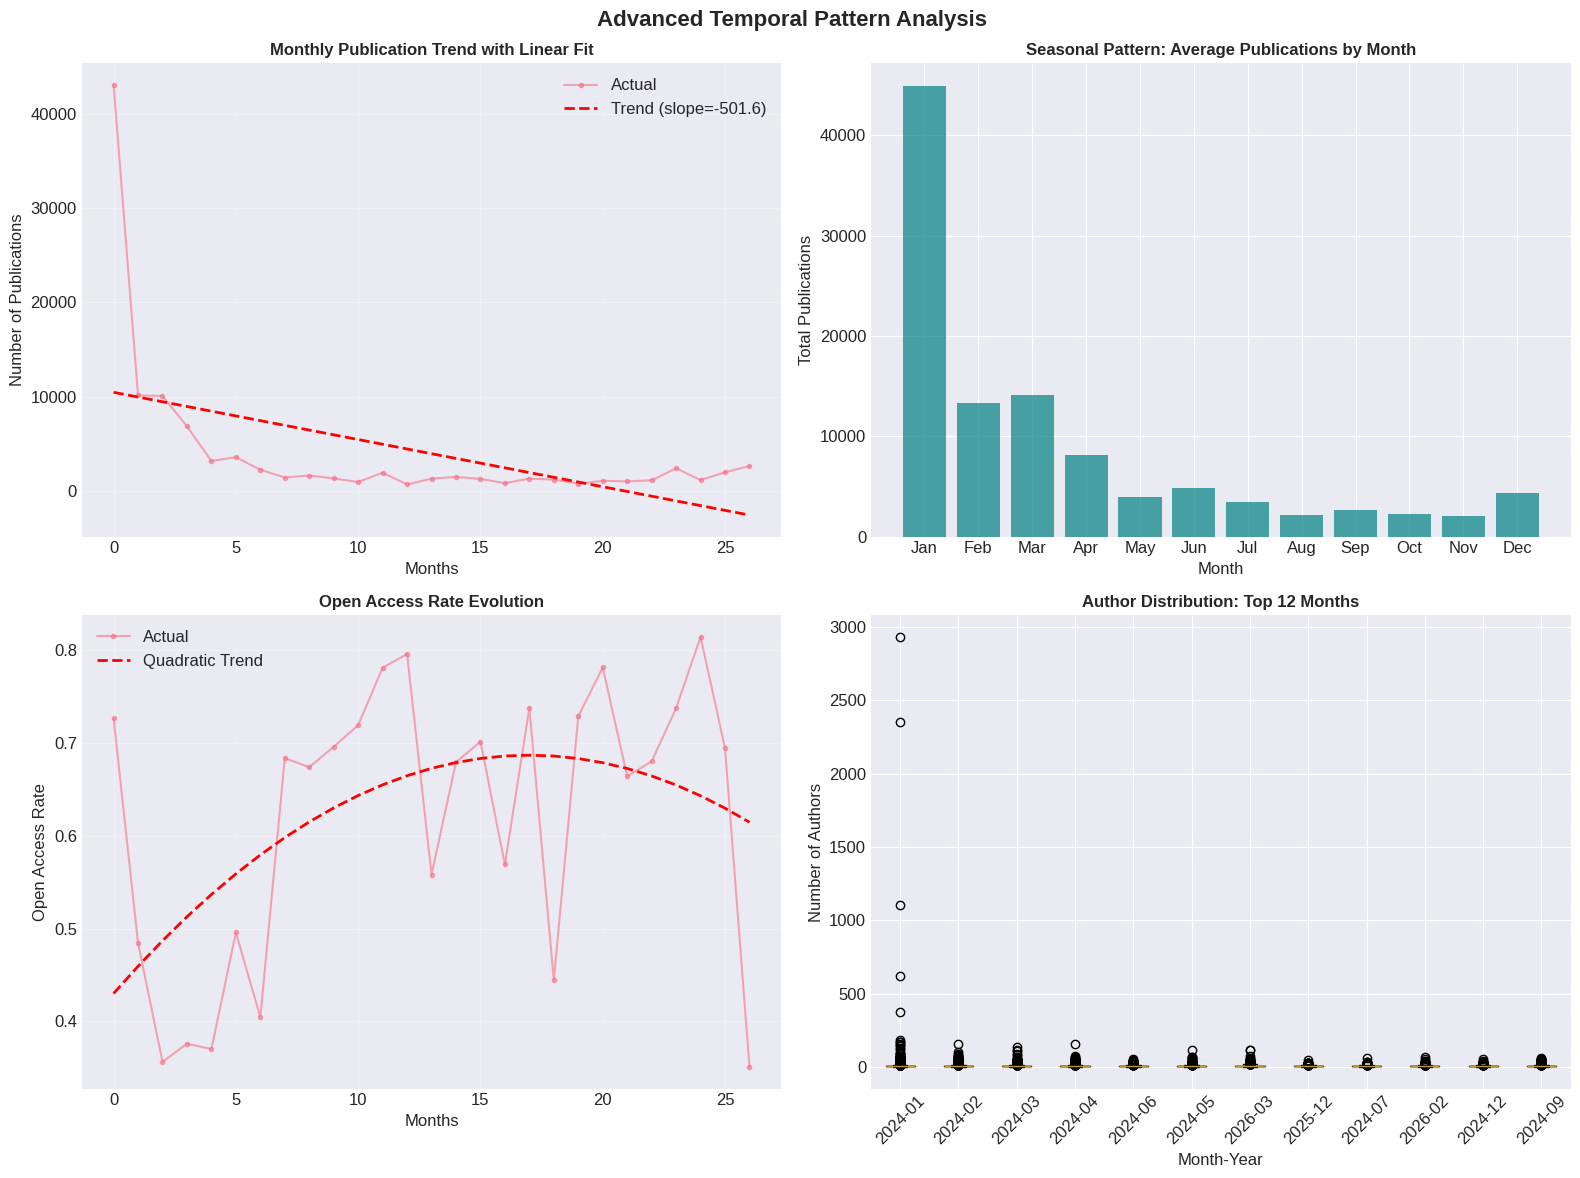

In [9]:




# Data preprocessing with error handling
df['pub_year'] = df['pub_year'].astype(int)
df['open_access'] = df['open_access'].astype(bool)

# Handle month column - create valid date only where possible
df['pub_month_num_clean'] = pd.to_numeric(df['pub_month_num'], errors='coerce')
df['valid_date'] = df['pub_month_num_clean'].notna() & (df['pub_month_num_clean'] >= 1) & (df['pub_month_num_clean'] <= 12)

# Create date for analysis only for valid entries
df.loc[df['valid_date'], 'date_for_analysis'] = pd.to_datetime(
    df.loc[df['valid_date'], 'pub_year'].astype(str) + '-' + 
    df.loc[df['valid_date'], 'pub_month_num_clean'].astype(int).astype(str) + '-01',
    errors='coerce'
)

print(f"Records with valid dates: {df['valid_date'].sum():,} / {len(df):,}")
print(f"Records with unknown months: {(~df['valid_date']).sum():,}")

# Advanced temporal analysis with error handling
fig, axes = plt.subplots(2, 3, figsize=(20, 12))
fig.suptitle('Advanced Temporal Analysis of Biomedical Research Publications', fontsize=16, fontweight='bold')

# 1. Cumulative publications over time (only valid dates)
df_valid = df[df['valid_date']].copy()
df_valid = df_valid.sort_values('date_for_analysis')
df_valid['cumulative_count'] = range(1, len(df_valid) + 1)

axes[0, 0].plot(df_valid['date_for_analysis'], df_valid['cumulative_count'], 
                linewidth=2, color='darkblue', alpha=0.7)
axes[0, 0].set_title('Cumulative Publications Over Time', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Date')
axes[0, 0].set_ylabel('Cumulative Number of Publications')
axes[0, 0].grid(True, alpha=0.3)
axes[0, 0].tick_params(axis='x', rotation=45)

# 2. Monthly publication trends (bar chart instead of heatmap for clarity)
monthly_counts = df[df['valid_date']].groupby(['pub_year', 'pub_month_num_clean']).size().reset_index(name='count')
monthly_counts['date'] = pd.to_datetime(
    monthly_counts['pub_year'].astype(str) + '-' + 
    monthly_counts['pub_month_num_clean'].astype(int).astype(str) + '-01'
)

axes[0, 1].bar(range(len(monthly_counts)), monthly_counts['count'], color='coral', alpha=0.7)
axes[0, 1].set_title('Monthly Publication Counts', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('Time (Months)')
axes[0, 1].set_ylabel('Number of Publications')
# Show every 6th month label
xtick_positions = range(0, len(monthly_counts), 6)
xtick_labels = [monthly_counts['date'].iloc[i].strftime('%Y-%m') for i in xtick_positions if i < len(monthly_counts)]
axes[0, 1].set_xticks(xtick_positions[:len(xtick_labels)])
axes[0, 1].set_xticklabels(xtick_labels, rotation=45)

# 3. Publications heatmap with year-month pivot (handle missing months)
# Create complete year-month grid
years = sorted(df['pub_year'].unique())
months = list(range(1, 13))
pivot_data = []
for year in years:
    for month in months:
        count = len(df[(df['pub_year'] == year) & (df['pub_month_num_clean'] == month) & df['valid_date']])
        pivot_data.append([year, month, count])

pivot_df = pd.DataFrame(pivot_data, columns=['Year', 'Month', 'Count'])
pivot_table = pivot_df.pivot(index='Year', columns='Month', values='Count').fillna(0)

# Create heatmap
sns.heatmap(pivot_table, annot=True, fmt='.0f', cmap='YlOrRd', 
            ax=axes[0, 2], cbar_kws={'label': 'Number of Publications'})
axes[0, 2].set_title('Publications Heatmap: Year vs Month', fontsize=12, fontweight='bold')
axes[0, 2].set_xlabel('Month')
axes[0, 2].set_ylabel('Year')

# 4. Open access trends over time (with proper aggregation)
oa_trend = df[df['valid_date']].groupby(df['date_for_analysis'].dt.to_period('M'))['open_access'].agg(['mean', 'count'])
oa_trend.index = oa_trend.index.astype(str)

axes[1, 0].plot(range(len(oa_trend)), oa_trend['mean'], marker='o', linewidth=2, color='green', markersize=4)
# Add confidence intervals (standard error)
se = np.sqrt(oa_trend['mean'] * (1 - oa_trend['mean']) / oa_trend['count'])
axes[1, 0].fill_between(range(len(oa_trend)), 
                        oa_trend['mean'] - 1.96 * se, 
                        oa_trend['mean'] + 1.96 * se, 
                        alpha=0.2, color='green')
axes[1, 0].set_title('Open Access Proportion Over Time\n(with 95% CI)', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('Month')
axes[1, 0].set_ylabel('Proportion Open Access')
axes[1, 0].set_ylim(0, 1)
axes[1, 0].axhline(y=df['open_access'].mean(), color='red', linestyle='--', alpha=0.5, label='Overall Average')
axes[1, 0].legend()
# Set x-ticks to show every 3 months
xtick_positions = range(0, len(oa_trend), 3)
xtick_labels = [oa_trend.index[i] for i in xtick_positions if i < len(oa_trend)]
axes[1, 0].set_xticks(xtick_positions[:len(xtick_labels)])
axes[1, 0].set_xticklabels(xtick_labels, rotation=45)

# 5. Author count trends over time
author_trend = df[df['valid_date']].groupby(df['date_for_analysis'].dt.to_period('M'))['authors_count'].agg(['mean', 'std', 'count'])
author_trend.index = author_trend.index.astype(str)

axes[1, 1].plot(range(len(author_trend)), author_trend['mean'], marker='s', linewidth=2, color='purple', markersize=4)
# Add confidence intervals
ci = 1.96 * author_trend['std'] / np.sqrt(author_trend['count'])
axes[1, 1].fill_between(range(len(author_trend)), 
                        author_trend['mean'] - ci, 
                        author_trend['mean'] + ci, 
                        alpha=0.2, color='purple')
axes[1, 1].set_title('Average Authors per Paper Over Time\n(with 95% CI)', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('Month')
axes[1, 1].set_ylabel('Average Authors Count')
axes[1, 1].axhline(y=df['authors_count'].mean(), color='red', linestyle='--', alpha=0.5, label='Overall Average')
axes[1, 1].legend()
axes[1, 1].set_xticks(xtick_positions[:len(xtick_labels)])
axes[1, 1].set_xticklabels(xtick_labels, rotation=45)

# 6. Publication velocity (rate of publications per month)
monthly_counts_ts = df[df['valid_date']].groupby(df['date_for_analysis'].dt.to_period('M')).size()
monthly_counts_ts.index = monthly_counts_ts.index.astype(str)

# Calculate rolling average
rolling_avg = monthly_counts_ts.rolling(window=3, min_periods=1).mean()

axes[1, 2].bar(range(len(monthly_counts_ts)), monthly_counts_ts.values, alpha=0.5, label='Monthly Count', color='steelblue')
axes[1, 2].plot(range(len(rolling_avg)), rolling_avg.values, 'r-', linewidth=2, label='3-Month Rolling Average')
axes[1, 2].set_title('Publication Velocity\n(Monthly Output with Rolling Average)', fontsize=12, fontweight='bold')
axes[1, 2].set_xlabel('Month')
axes[1, 2].set_ylabel('Number of Publications')
axes[1, 2].legend()
axes[1, 2].set_xticks(xtick_positions[:len(xtick_labels)])
axes[1, 2].set_xticklabels(xtick_labels, rotation=45)

plt.tight_layout()
plt.show()

# Additional visualization: Missing months analysis - FIXED VERSION
fig, ax = plt.subplots(figsize=(12, 6))

# Get all unique years and ensure consistent indexing
all_years = sorted(df['pub_year'].unique())
missing_by_year = df[~df['valid_date']].groupby('pub_year').size().reindex(all_years, fill_value=0)
complete_by_year = df[df['valid_date']].groupby('pub_year').size().reindex(all_years, fill_value=0)

x = np.arange(len(all_years))
width = 0.35

bars1 = ax.bar(x - width/2, complete_by_year.values, width, label='With Valid Months', color='green', alpha=0.7)
bars2 = ax.bar(x + width/2, missing_by_year.values, width, label='Missing Month Info', color='red', alpha=0.7)

ax.set_xlabel('Year')
ax.set_ylabel('Number of Publications')
ax.set_title('Data Completeness: Month Information by Year', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(all_years)
ax.legend()
ax.grid(True, alpha=0.3)

# Add value labels on bars
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        if height > 0:
            ax.annotate(f'{int(height)}',
                       xy=(bar.get_x() + bar.get_width() / 2, height),
                       xytext=(0, 3),
                       textcoords="offset points",
                       ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

# Statistical summary of temporal patterns

print("TEMPORAL PATTERN ANALYSIS SUMMARY")


print("\n Publication Trends by Year:")
yearly_stats = df.groupby('pub_year').agg({
    'pmid': 'count',
    'open_access': 'mean',
    'authors_count': 'mean',
    'abstract_words': 'mean'
}).round(2)
yearly_stats.columns = ['Publications', 'Open Access Rate', 'Avg Authors', 'Avg Abstract Length']
print(yearly_stats)

print("\n Growth Rates:")
for i in range(len(yearly_stats) - 1):
    year1, year2 = yearly_stats.index[i], yearly_stats.index[i+1]
    growth = ((yearly_stats.iloc[i+1]['Publications'] - yearly_stats.iloc[i]['Publications']) / 
              yearly_stats.iloc[i]['Publications'] * 100)
    print(f"  {year1} → {year2}: {growth:.1f}% growth in publications")

print("\n Missing Data Impact:")
print(f"  Total records with missing month: {(~df['valid_date']).sum():,} ({((~df['valid_date']).sum()/len(df))*100:.1f}%)")
print(f"  These records are excluded from time-series analysis")
print(f"  Recommendation: Use year-level analysis for these records")

# Additional insights about temporal distribution
print("\n Temporal Distribution Insights:")
print(f"  Months with most publications: {monthly_counts.nlargest(5, 'count')[['date', 'count']].to_string(index=False)}")
print(f"  Months with fewest publications: {monthly_counts.nsmallest(5, 'count')[['date', 'count']].to_string(index=False)}")

# Calculate and display publication velocity trends
if len(monthly_counts_ts) > 1:
    first_half_avg = monthly_counts_ts.iloc[:len(monthly_counts_ts)//2].mean()
    second_half_avg = monthly_counts_ts.iloc[len(monthly_counts_ts)//2:].mean()
    print(f"\n Publication Velocity:")
    print(f"  Average publications per month (first half): {first_half_avg:.0f}")
    print(f"  Average publications per month (second half): {second_half_avg:.0f}")
    print(f"  Growth rate: {((second_half_avg - first_half_avg) / first_half_avg * 100):.1f}%")


# Create a more detailed monthly trend visualization with seasonal decomposition
from scipy import stats

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Advanced Temporal Pattern Analysis', fontsize=16, fontweight='bold')

# Monthly publication pattern with trend line
monthly_data = monthly_counts_ts.values
x_months = np.arange(len(monthly_data))
z = np.polyfit(x_months, monthly_data, 1)
p = np.poly1d(z)

axes[0, 0].plot(x_months, monthly_data, 'o-', alpha=0.6, label='Actual', markersize=3)
axes[0, 0].plot(x_months, p(x_months), 'r--', linewidth=2, label=f'Trend (slope={z[0]:.1f})')
axes[0, 0].set_title('Monthly Publication Trend with Linear Fit', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Months')
axes[0, 0].set_ylabel('Number of Publications')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Seasonal pattern (if enough data)
if len(monthly_data) >= 12:
    # Calculate average by month number across years
    seasonal_pattern = df[df['valid_date']].groupby('pub_month_num_clean')['pmid'].count()
    axes[0, 1].bar(seasonal_pattern.index, seasonal_pattern.values, color='teal', alpha=0.7)
    axes[0, 1].set_title('Seasonal Pattern: Average Publications by Month', fontsize=12, fontweight='bold')
    axes[0, 1].set_xlabel('Month')
    axes[0, 1].set_ylabel('Total Publications')
    axes[0, 1].set_xticks(range(1, 13))
    axes[0, 1].set_xticklabels(['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 
                               'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])

# Open access trend with polynomial fit
oa_data = oa_trend['mean'].values
if len(oa_data) > 1:
    z_oa = np.polyfit(x_months[:len(oa_data)], oa_data, 2)
    p_oa = np.poly1d(z_oa)
    axes[1, 0].plot(x_months[:len(oa_data)], oa_data, 'o-', alpha=0.6, label='Actual', markersize=3)
    axes[1, 0].plot(x_months[:len(oa_data)], p_oa(x_months[:len(oa_data)]), 'r--', linewidth=2, 
                    label=f'Quadratic Trend')
    axes[1, 0].set_title('Open Access Rate Evolution', fontsize=12, fontweight='bold')
    axes[1, 0].set_xlabel('Months')
    axes[1, 0].set_ylabel('Open Access Rate')
    axes[1, 0].legend()
    axes[1, 0].grid(True, alpha=0.3)

# Author count distribution over time (boxplot by year)
df_valid_years = df[df['valid_date']].copy()
df_valid_years['year_month'] = df_valid_years['date_for_analysis'].dt.to_period('M')
top_months = df_valid_years.groupby('year_month').size().nlargest(12).index
df_top_months = df_valid_years[df_valid_years['year_month'].isin(top_months)]

month_names = [str(m) for m in top_months]
df_top_months['month_label'] = df_top_months['year_month'].astype(str)
axes[1, 1].boxplot([df_top_months[df_top_months['month_label'] == m]['authors_count'].values 
                    for m in month_names], labels=month_names, vert=True)
axes[1, 1].set_title('Author Distribution: Top 12 Months', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('Month-Year')
axes[1, 1].set_ylabel('Number of Authors')
axes[1, 1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()


# Geographic Analysis

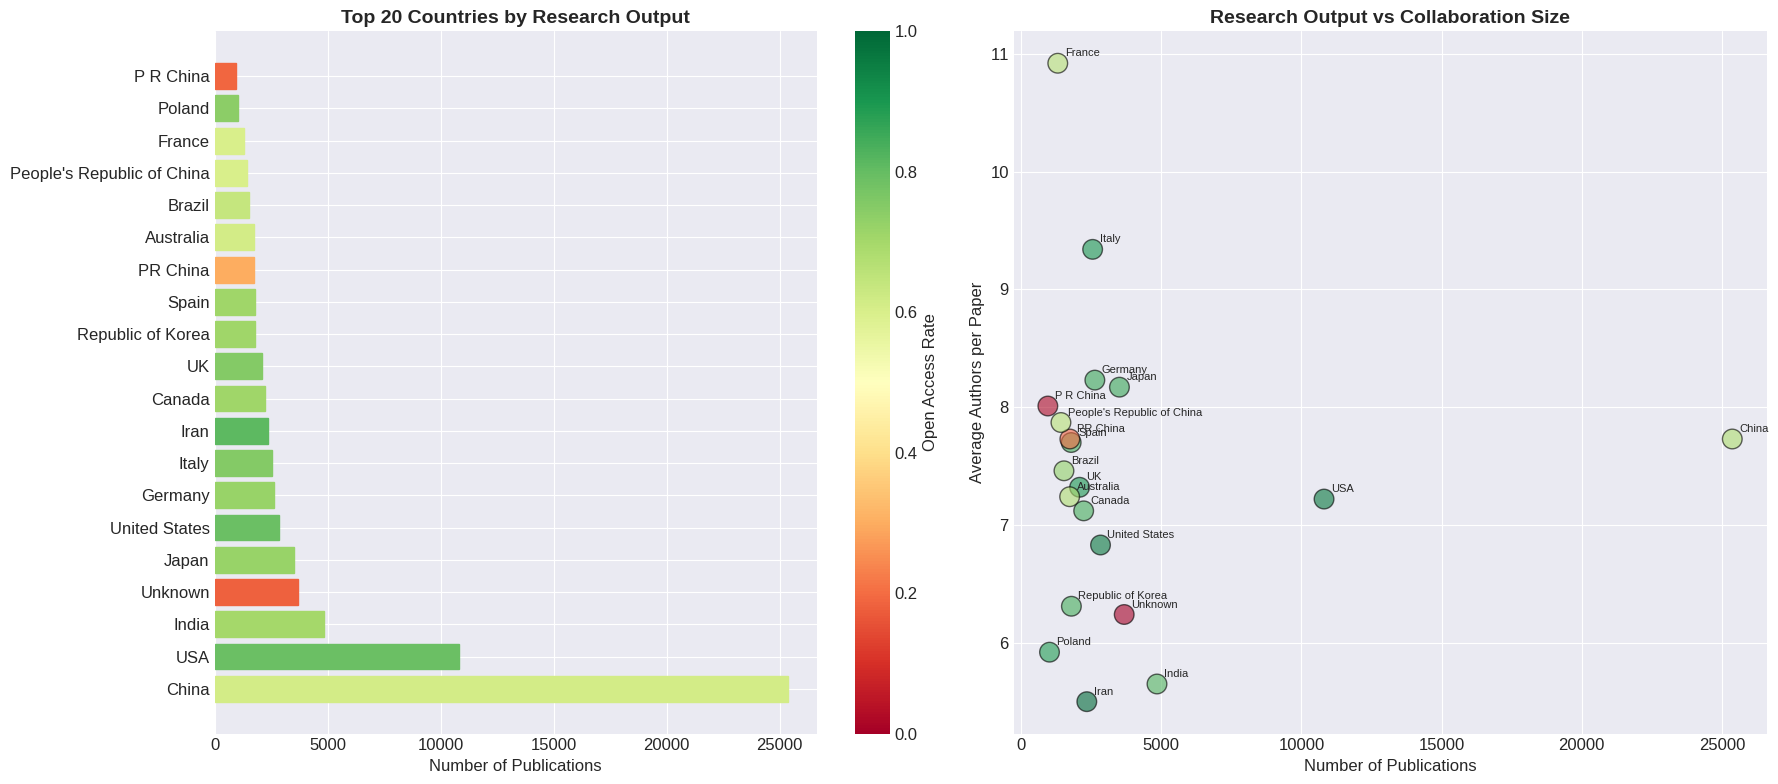

In [10]:
# Country-level analysis
country_stats = df.groupby('country').agg({
    'pmid': 'count',
    'authors_count': 'mean',
    'open_access': 'mean'
}).round(2).rename(columns={'pmid': 'publications', 
                            'authors_count': 'avg_authors',
                            'open_access': 'open_access_rate'})

# Top 20 countries
top_countries = country_stats.nlargest(20, 'publications')

fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# Horizontal bar chart for top countries
bars = axes[0].barh(range(len(top_countries)), top_countries['publications'].values)
axes[0].set_yticks(range(len(top_countries)))
axes[0].set_yticklabels(top_countries.index)
axes[0].set_xlabel('Number of Publications')
axes[0].set_title('Top 20 Countries by Research Output', fontsize=14, fontweight='bold')

# Color bars by open access rate
colors = plt.cm.RdYlGn(top_countries['open_access_rate'].values)
for bar, color in zip(bars, colors):
    bar.set_color(color)

# Add colorbar
sm = plt.cm.ScalarMappable(cmap='RdYlGn', norm=plt.Normalize(0, 1))
sm.set_array([])
cbar = plt.colorbar(sm, ax=axes[0])
cbar.set_label('Open Access Rate')

# Scatter plot: Publications vs Avg Authors
axes[1].scatter(top_countries['publications'], top_countries['avg_authors'], 
                c=top_countries['open_access_rate'], 
                cmap='RdYlGn', s=200, alpha=0.6, edgecolors='black', linewidth=1)
axes[1].set_xlabel('Number of Publications')
axes[1].set_ylabel('Average Authors per Paper')
axes[1].set_title('Research Output vs Collaboration Size', fontsize=14, fontweight='bold')

# Add country labels
for idx, row in top_countries.iterrows():
    axes[1].annotate(idx, (row['publications'], row['avg_authors']), 
                     xytext=(5, 5), textcoords='offset points', fontsize=8)

plt.tight_layout()
plt.show()

# Geographical map visualization (if country coordinates available)
# This would require geocoding, but we can show distribution
fig = px.choropleth(country_stats.reset_index(), 
                    locations='country', 
                    locationmode='country names',
                    color='publications',
                    hover_name='country',
                    color_continuous_scale='Viridis',
                    title='Global Distribution of Biomedical Research Publications')
fig.show()

# Text Analysis & NLP Insights

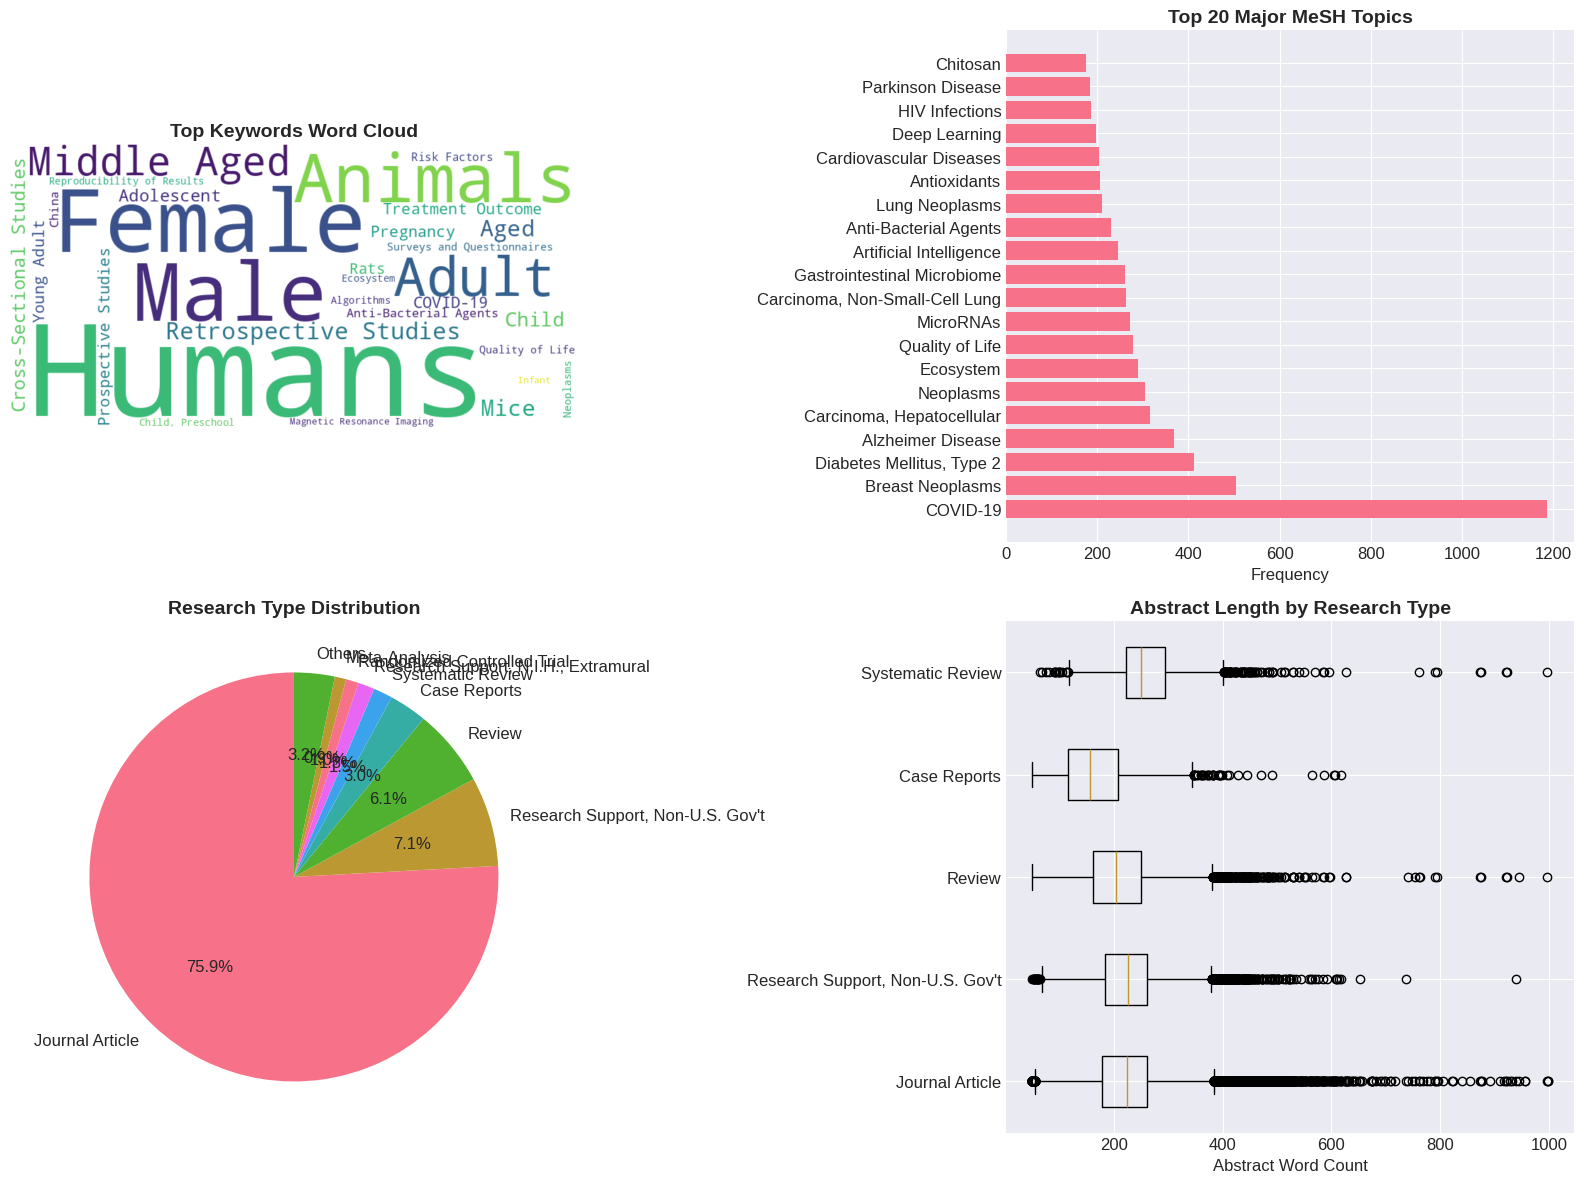

In [11]:
# Keyword and topic analysis
all_keywords = df['keywords'].dropna().str.split('; ').sum()
keyword_counts = Counter(all_keywords).most_common(30)

# Major topics
major_topics = df['major_topic'].value_counts().head(20)

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Top keywords wordcloud
wordcloud = WordCloud(width=800, height=400, background_color='white', 
                      max_words=100, colormap='viridis').generate_from_frequencies(dict(keyword_counts[:50]))
axes[0, 0].imshow(wordcloud, interpolation='bilinear')
axes[0, 0].axis('off')
axes[0, 0].set_title('Top Keywords Word Cloud', fontsize=14, fontweight='bold')

# Top major topics bar chart
major_topics_df = pd.DataFrame(major_topics).reset_index()
major_topics_df.columns = ['Topic', 'Count']
axes[0, 1].barh(range(len(major_topics_df)), major_topics_df['Count'].values)
axes[0, 1].set_yticks(range(len(major_topics_df)))
axes[0, 1].set_yticklabels(major_topics_df['Topic'])
axes[0, 1].set_xlabel('Frequency')
axes[0, 1].set_title('Top 20 Major MeSH Topics', fontsize=14, fontweight='bold')

# Research type distribution
research_types = df['research_type'].dropna().str.split('; ').sum()
type_counts = Counter(research_types).most_common(15)
type_df = pd.DataFrame(type_counts, columns=['Type', 'Count'])

# Create pie chart for top research types
top_types = type_df.head(8)
others_count = type_df[8:]['Count'].sum()
type_pie_data = pd.concat([top_types, pd.DataFrame([['Others', others_count]], columns=['Type', 'Count'])])
axes[1, 0].pie(type_pie_data['Count'].values, labels=type_pie_data['Type'], 
               autopct='%1.1f%%', startangle=90)
axes[1, 0].set_title('Research Type Distribution', fontsize=14, fontweight='bold')

# Abstract length by research type
# Get top research types for boxplot
top_types_list = [t[0] for t in type_counts[:5]]
type_abstract_length = {}
for t in top_types_list:
    mask = df['research_type'].fillna('').str.contains(t, na=False)
    type_abstract_length[t] = df[mask]['abstract_words'].values

bp_data = [type_abstract_length[t] for t in top_types_list]
axes[1, 1].boxplot(bp_data, labels=top_types_list, vert=False)
axes[1, 1].set_xlabel('Abstract Word Count')
axes[1, 1].set_title('Abstract Length by Research Type', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

# Multi-Variate Analysis

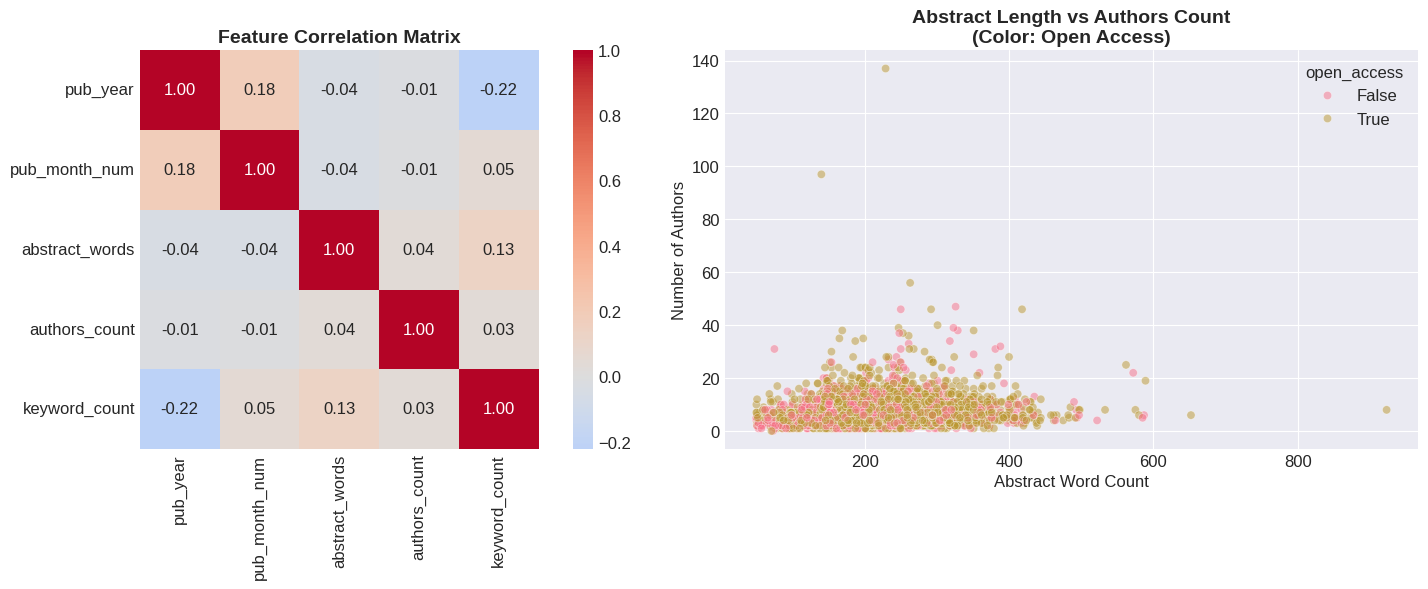

In [12]:
# Create correlation matrix for numeric features
numeric_features = ['pub_year', 'pub_month_num', 'abstract_words', 'authors_count', 'keyword_count']
corr_matrix = df[numeric_features].corr()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Correlation heatmap
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', 
            center=0, square=True, ax=axes[0])
axes[0].set_title('Feature Correlation Matrix', fontsize=14, fontweight='bold')

# Pairplot for key features (sample for performance)
sample_df = df[numeric_features + ['open_access']].sample(min(5000, len(df)))
sns.scatterplot(data=sample_df, x='abstract_words', y='authors_count', 
                hue='open_access', alpha=0.5, ax=axes[1])
axes[1].set_title('Abstract Length vs Authors Count\n(Color: Open Access)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Abstract Word Count')
axes[1].set_ylabel('Number of Authors')

plt.tight_layout()
plt.show()

#  Research Impact & Collaboration Patterns

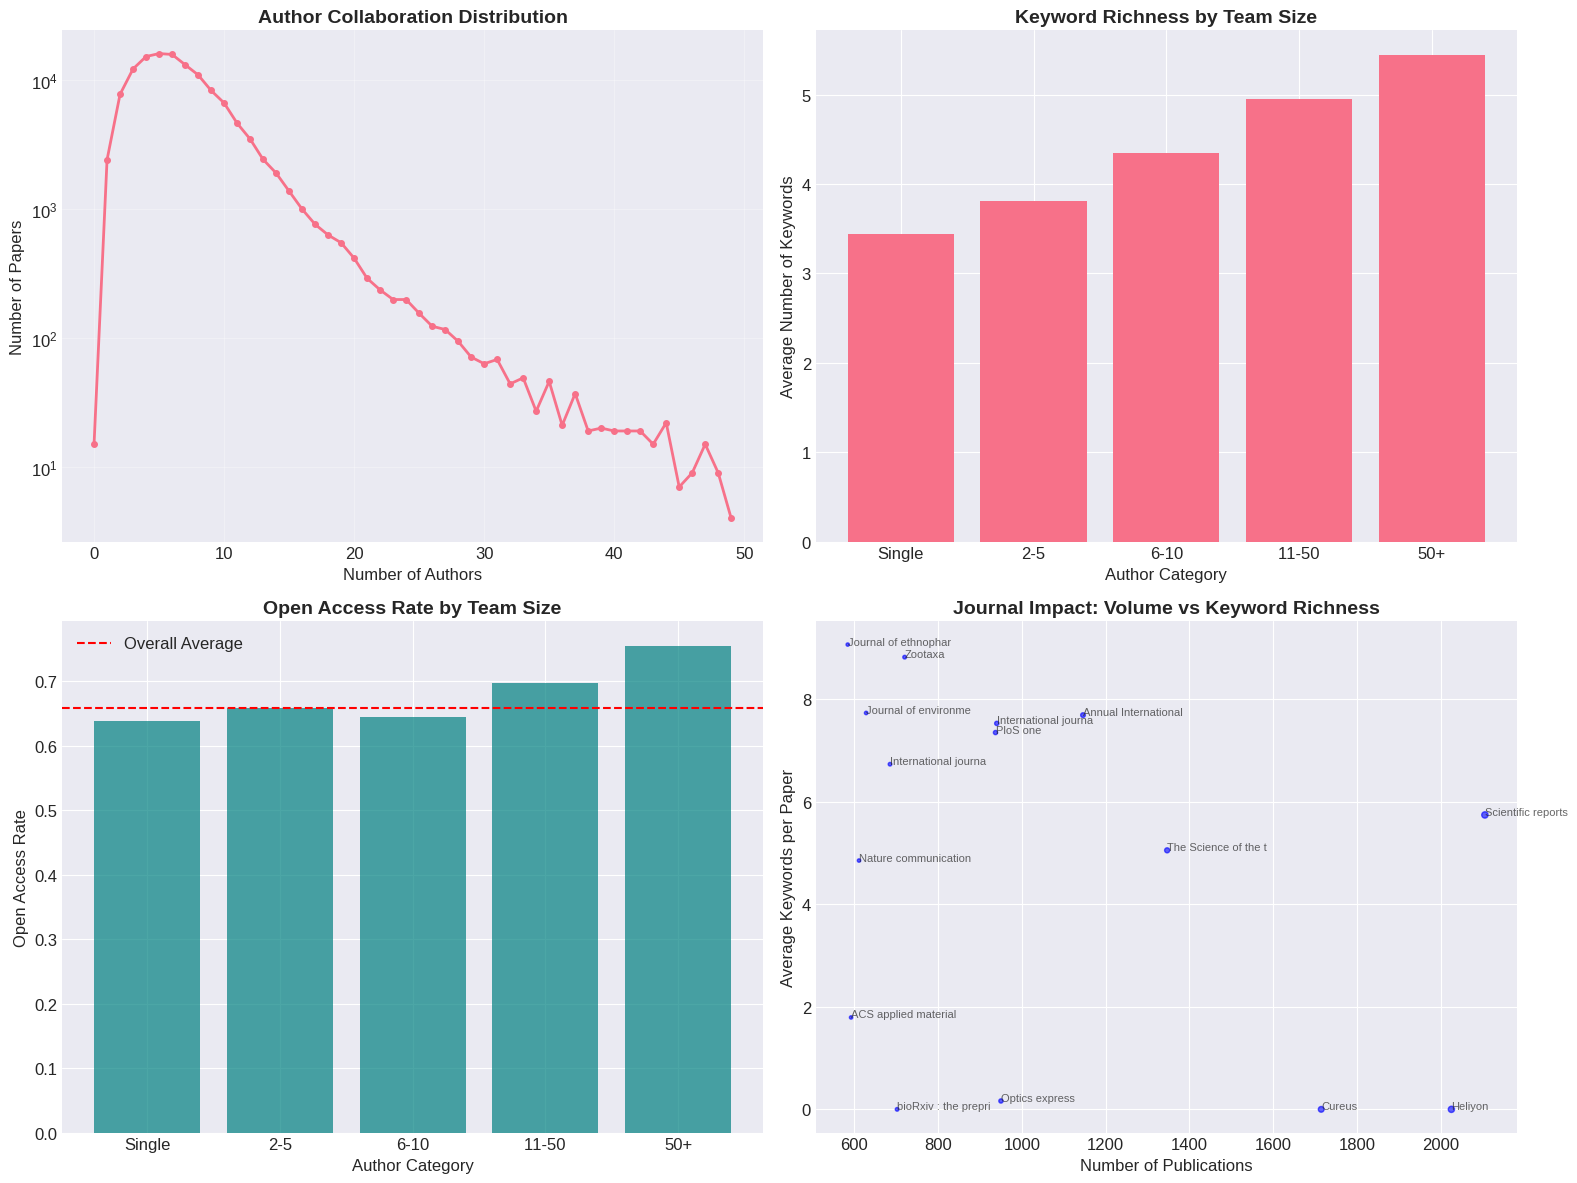

In [13]:
# Collaboration analysis
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Author count distribution
author_dist = df['authors_count'].value_counts().sort_index()
axes[0, 0].plot(author_dist.index[:50], author_dist.values[:50], 
                marker='o', linewidth=2, markersize=4)
axes[0, 0].set_xlabel('Number of Authors')
axes[0, 0].set_ylabel('Number of Papers')
axes[0, 0].set_title('Author Collaboration Distribution', fontsize=14, fontweight='bold')
axes[0, 0].set_yscale('log')
axes[0, 0].grid(True, alpha=0.3)

# Keyword richness by author count
keyword_richness = df.groupby('author_category')['keyword_count'].mean().sort_index()
axes[0, 1].bar(keyword_richness.index, keyword_richness.values)
axes[0, 1].set_xlabel('Author Category')
axes[0, 1].set_ylabel('Average Number of Keywords')
axes[0, 1].set_title('Keyword Richness by Team Size', fontsize=14, fontweight='bold')

# Open access by author category
oa_by_author = df.groupby('author_category')['open_access'].mean().sort_index()
axes[1, 0].bar(oa_by_author.index, oa_by_author.values, color='teal', alpha=0.7)
axes[1, 0].set_xlabel('Author Category')
axes[1, 0].set_ylabel('Open Access Rate')
axes[1, 0].set_title('Open Access Rate by Team Size', fontsize=14, fontweight='bold')
axes[1, 0].axhline(y=df['open_access'].mean(), color='red', linestyle='--', 
                   label='Overall Average', linewidth=1.5)
axes[1, 0].legend()

# Top journals by impact (using keyword count as proxy for complexity)
top_journals_impact = df.groupby('journal').agg({
    'keyword_count': 'mean',
    'pmid': 'count'
}).sort_values('pmid', ascending=False).head(15)

axes[1, 1].scatter(top_journals_impact['pmid'], top_journals_impact['keyword_count'], 
                   s=top_journals_impact['pmid']/100, alpha=0.6, c='blue')
for idx, row in top_journals_impact.iterrows():
    axes[1, 1].annotate(idx[:20], (row['pmid'], row['keyword_count']), 
                        fontsize=8, alpha=0.7)
axes[1, 1].set_xlabel('Number of Publications')
axes[1, 1].set_ylabel('Average Keywords per Paper')
axes[1, 1].set_title('Journal Impact: Volume vs Keyword Richness', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

# Interactive Dashboard Components

In [14]:

# Use monthly aggregation (better signal, less noise)
ts = df[df['valid_date']].copy()
ts['year_month'] = ts['date_for_analysis'].dt.to_period('M').astype(str)

monthly = ts.groupby('year_month').agg({
    'pmid': 'count',
    'authors_count': 'mean',
    'open_access': 'mean'
}).reset_index()

# Create subplot (KEY FIX: separate y-axes)
from plotly.subplots import make_subplots

fig = make_subplots(specs=[[{"secondary_y": True}]])

# Publications (primary axis)
fig.add_trace(go.Scatter(
    x=monthly['year_month'],
    y=monthly['pmid'],
    name='Publications',
    mode='lines+markers'
), secondary_y=False)

# Avg Authors
fig.add_trace(go.Scatter(
    x=monthly['year_month'],
    y=monthly['authors_count'],
    name='Avg Authors',
    mode='lines+markers'
), secondary_y=True)

# Open Access
fig.add_trace(go.Scatter(
    x=monthly['year_month'],
    y=monthly['open_access'],
    name='Open Access Rate',
    mode='lines+markers',
    line=dict(dash='dot')
), secondary_y=True)

fig.update_layout(
    title='Biomedical Research Trends (Monthly)',
    template='plotly_white',
    hovermode='x unified',
    height=550
)

fig.update_yaxes(title_text="Publications", secondary_y=False)
fig.update_yaxes(title_text="Authors / Open Access Rate", secondary_y=True)

fig.show()


# Filter meaningful countries (avoid noise from very small counts)
country_stats = df.groupby('country').agg({
    'pmid': 'count',
    'open_access': 'mean',
    'authors_count': 'mean'
}).reset_index()

# Keep only strong-signal countries
country_stats = country_stats[country_stats['pmid'] > country_stats['pmid'].quantile(0.75)]

fig = px.scatter(
    country_stats,
    x='pmid',
    y='authors_count',
    size='pmid',
    color='open_access',
    hover_name='country',
    title=' Research Output vs Collaboration (Top Countries)',
    labels={
        'pmid': 'Publications',
        'authors_count': 'Avg Authors',
        'open_access': 'Open Access Rate'
    }
)

fig.update_traces(marker=dict(opacity=0.8))
fig.show()

# Temporal Imbalance Visualization & Mitigation Strategies

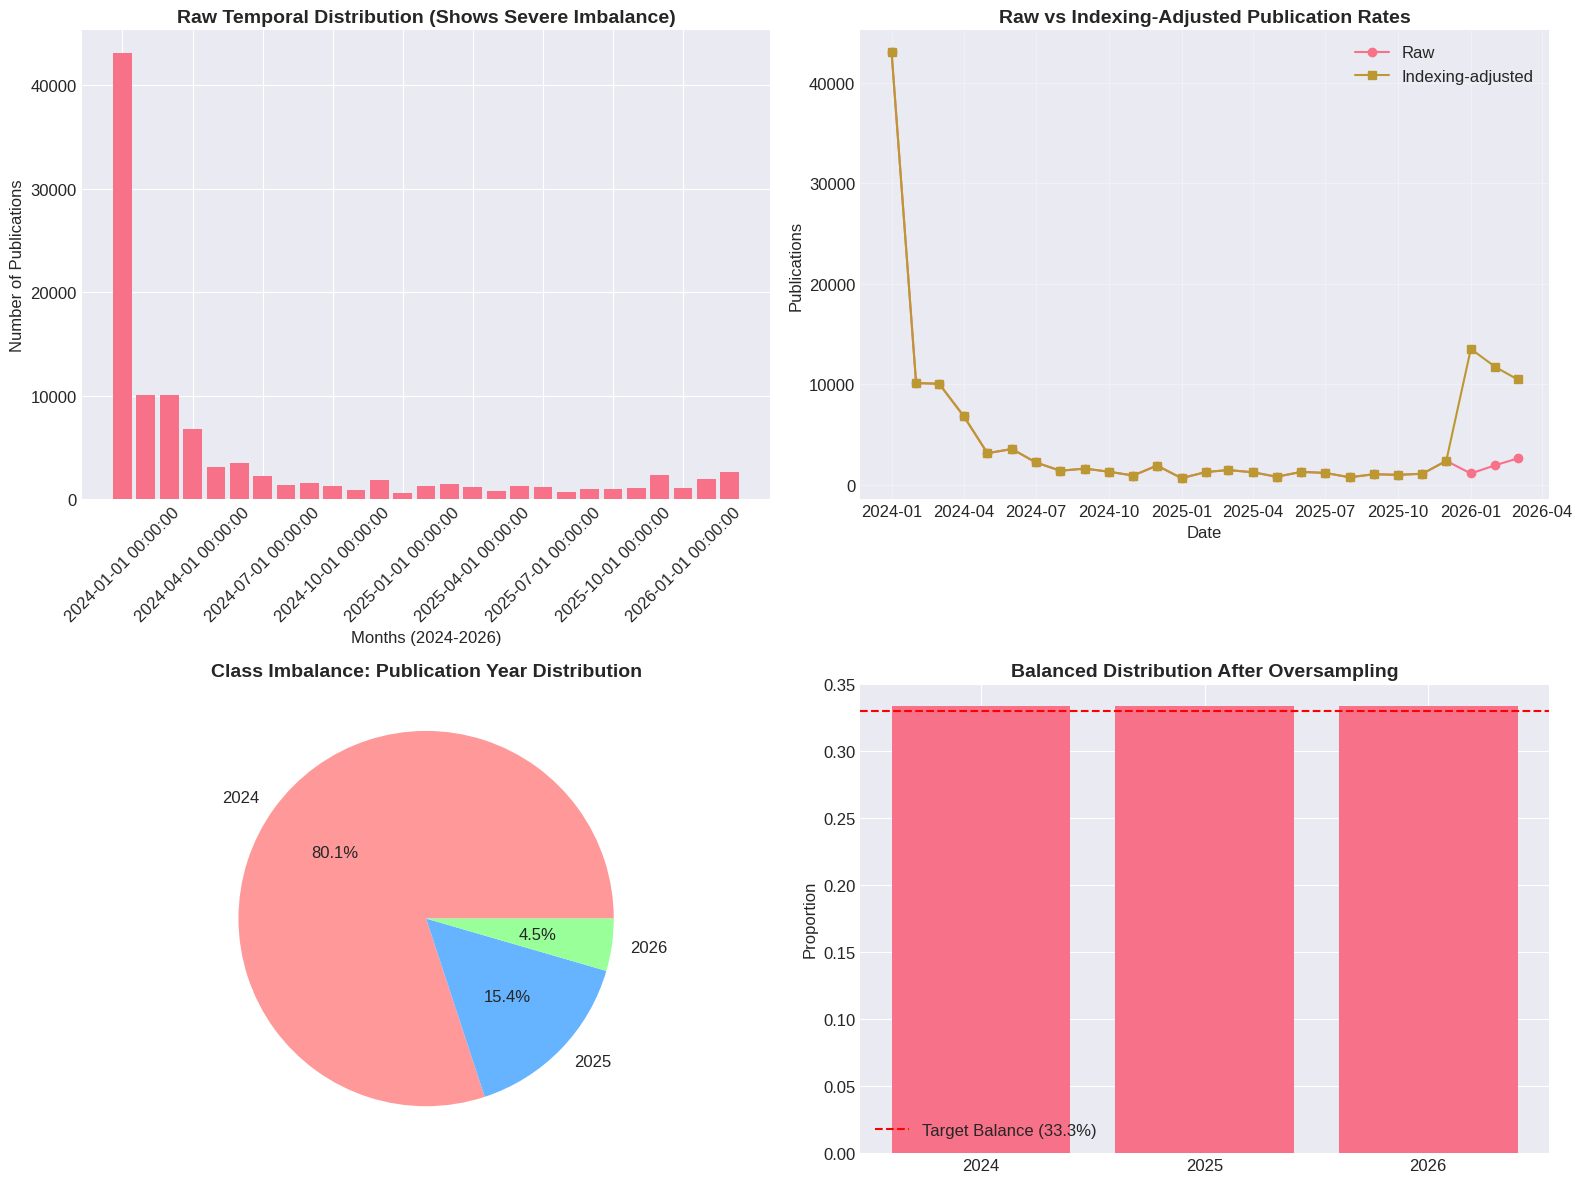

In [15]:
# Visualize the temporal imbalance challenge
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Raw temporal distribution
monthly_counts = df.groupby('date_for_analysis').size()
axes[0, 0].bar(range(len(monthly_counts)), monthly_counts.values)
axes[0, 0].set_title('Raw Temporal Distribution (Shows Severe Imbalance)', fontsize=14, fontweight='bold')
axes[0, 0].set_xlabel('Months (2024-2026)')
axes[0, 0].set_ylabel('Number of Publications')
axes[0, 0].set_xticks(range(0, len(monthly_counts), 3))
axes[0, 0].set_xticklabels(monthly_counts.index[::3], rotation=45)

# Normalized view (per-month average based on indexing lag)
# Simulate indexing lag correction
months_in_index = len(monthly_counts)
projected_full_counts = monthly_counts.copy()
for i, (date, count) in enumerate(monthly_counts.items()):
    if date.year == 2026:
        projected_full_counts.iloc[i] = count * (12 / (date.month if date.month > 0 else 1))

axes[0, 1].plot(monthly_counts.index, monthly_counts.values, label='Raw', marker='o')
axes[0, 1].plot(projected_full_counts.index, projected_full_counts.values, 
                label='Indexing-adjusted', marker='s')
axes[0, 1].set_title('Raw vs Indexing-Adjusted Publication Rates', fontsize=14, fontweight='bold')
axes[0, 1].set_xlabel('Date')
axes[0, 1].set_ylabel('Publications')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# Class imbalance visualization
year_proportions = df['pub_year'].value_counts(normalize=True)
axes[1, 0].pie(year_proportions.values, labels=year_proportions.index, 
               autopct='%1.1f%%', colors=['#ff9999', '#66b3ff', '#99ff99'])
axes[1, 0].set_title('Class Imbalance: Publication Year Distribution', fontsize=14, fontweight='bold')

# Sampling strategy visualization
from sklearn.utils import resample

# Demonstrate sampling techniques
df_2024 = df[df['pub_year'] == 2024]
df_2025 = df[df['pub_year'] == 2025]
df_2026 = df[df['pub_year'] == 2026]

# Oversample minority classes
df_2025_oversampled = resample(df_2025, replace=True, n_samples=len(df_2024), random_state=42)
df_2026_oversampled = resample(df_2026, replace=True, n_samples=len(df_2024), random_state=42)

oversampled = pd.concat([df_2024, df_2025_oversampled, df_2026_oversampled])
oversampled_props = oversampled['pub_year'].value_counts(normalize=True)

# Plot balanced distribution
axes[1, 1].bar(range(len(oversampled_props)), oversampled_props.values)
axes[1, 1].set_xticks(range(len(oversampled_props)))
axes[1, 1].set_xticklabels(oversampled_props.index)
axes[1, 1].set_ylabel('Proportion')
axes[1, 1].set_title('Balanced Distribution After Oversampling', fontsize=14, fontweight='bold')
axes[1, 1].axhline(y=0.33, color='red', linestyle='--', label='Target Balance (33.3%)')
axes[1, 1].legend()

plt.tight_layout()
plt.show()